In [3]:
# Imports
from itertools import pairwise
import pickle
import networkx as nx
from a_star import A_star
from utils.fret_calculations import build_fret_graph

In [4]:
# Load in spectral data for natural chlorophylls in Et20 solvent
et20_spectra = pickle.load(open('./data/et20_spectra.pkl', 'rb'))
et20_molecules = list(et20_spectra.keys())
et20_graph = build_fret_graph(et20_molecules, et20_spectra);

In [5]:
source = 'CHL030_Ch f'
target = 'CHL006_Chl a'
heuristic = lambda p, n: 0 # Set heuristic to return 0 - reduces to dijkstra's
chlf_chla_path = A_star(et20_graph, source, target, heuristic)
chlf_chla_path

['CHL030_Ch f', 'CHL021_Chl d', 'CHL006_Chl a']

In [6]:
chl_keys = {'CHL070_Chl b2':'Chl B2', 'CHL215_Chl c':'Chl C', 'CHL205_BChl f [E,M]':'BChl F',
'CHL014_Chl b':'Chl B', 'CHL249_ProtoPhe a':'Phe A', 'CHL273_BPhe a':'BPhe A', 'CHL047_Phe b':'Phe B',
'CHL021_Chl d':'Chl D', 'CHL064_Chl a2':'Chl A2', 'CHL006_Chl a':'Chl A', 'CHL030_Ch f':'Chl F',
'CHL197_BChl d [E,E]+[P,M]':'BChl D', 'CHL052_Phe d':'Phe D', 'CHL202_BChl e [E,E]+[P,E]':'BChl E', 
'CHL231_Phe c':'Phe C'}
pos = nx.spring_layout(et20_graph)

In [7]:
max_weight = max([weight for _, _, weight in et20_graph.edges(data='weight')])

In [8]:
path_edgelist = [pair for pair in pairwise(chlf_chla_path)]

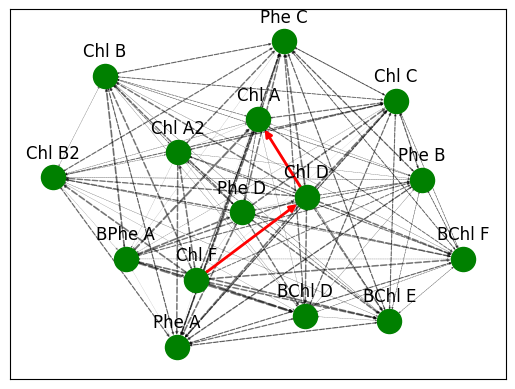

In [9]:
nx.draw_networkx_edges(
   et20_graph,
   pos=pos, alpha=0.5,
   style="dashed",arrowsize=3,
   width = [0.3*w for _, _, w in et20_graph.edges.data('weight')]
);

nx.draw_networkx_edges(
   et20_graph, width=2,
   pos=pos, alpha=1,
   edge_color='r',
   edgelist=path_edgelist
);

nx.draw_networkx_nodes(
   et20_graph,
   pos=pos,
   node_color='g',
);

nx.draw_networkx_labels(
   et20_graph, pos={k: (v[0], v[1]+0.15) for k,v in pos.items()},
   labels=chl_keys,
   font_size=12, font_family="sans-serif"
);